In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df=pd.read_csv('Titanic.csv',usecols=['Age','Fare','Survived'])

In [18]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [19]:
from sklearn.model_selection import train_test_split
import seaborn as sns

In [20]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [21]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [22]:
x_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [23]:
x_test

,Age,Fare
709,NaN,15.2458
439,31.0,10.5000
840,20.0,7.9250
720,6.0,33.0000
39,14.0,11.2417
...,...,...
433,17.0,7.1250
773,NaN,7.2250
25,38.0,31.3875
84,17.0,10.5000


In [28]:
# i want to make the new veriable to cheack or compare 
x_train['impu_Age']=x_train['Age']
x_test['impu_Age']=x_test['Age']

In [29]:
x_train.head()

,Age,Fare,impu_Age
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0


In [30]:
x_train['impu_Age'][x_train['impu_Age'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
# this code is first al the null value in impu-age is fill with random values from the age data
x_test['impu_Age'][x_test['impu_Age'].isnull()]=x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values
#  same but for test this code is first al the null value in impu-age is fill with random values from the age data

C:\Users\HEC\AppData\Local\Temp\ipykernel_28752\3624630906.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['impu_Age'][x_train['impu_Age'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
C:\Users\HE

In [34]:
x_train['impu_Age'].isnull().sum()

np.int64(0)

In [35]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values  # this is the part of above code it is for ony to see how they work

array([70.5 , 28.  , 19.  , 24.  , 18.  , 51.  , 24.  , 19.  ,  2.  ,
       35.  , 30.  , 17.  , 29.  , 48.  , 26.  ,  0.83, 22.  , 24.  ,
       25.  , 34.  , 27.  ,  3.  , 23.  , 50.  , 44.  , 40.  , 25.  ,
       22.  , 13.  , 47.  ,  1.  , 39.  , 51.  , 20.  , 51.  , 24.  ,
       43.  , 40.  ,  9.  , 28.  , 33.  , 30.  , 14.  , 31.  , 22.  ,
       42.  , 28.  , 22.  ,  0.75, 39.  , 74.  , 18.  , 33.  , 31.  ,
       30.  , 21.  , 35.  , 24.  , 49.  ,  7.  , 49.  , 23.  , 32.  ,
       21.  , 17.  , 36.  , 42.  ,  2.  , 18.  , 50.  , 34.  , 27.  ,
       33.  , 25.  , 36.  , 37.  , 45.  , 44.  , 32.  ,  8.  , 31.  ,
       27.  , 16.  , 20.  , 54.  , 28.  , 28.  , 34.  , 35.  , 21.  ,
       20.  , 11.  , 27.  , 36.  , 20.  , 16.  , 24.  , 41.  , 23.  ,
       53.  , 30.  ,  6.  , 51.  ,  3.  ,  4.  , 42.  ,  6.  ,  8.  ,
       27.  ,  3.  , 39.  ,  0.67, 36.  , 34.  , 21.  ,  1.  , 22.  ,
       20.  , 36.  , 35.  , 42.  , 52.  , 21.  , 29.  , 28.  , 32.  ,
       48.  , 31.  ,

C:\Users\HEC\AppData\Local\Temp\ipykernel_28752\1365355271.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='orignal',hist=False)
C:\Users\HEC\AppData\Local\Temp\ipykernel_28752\1365355271.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['impu

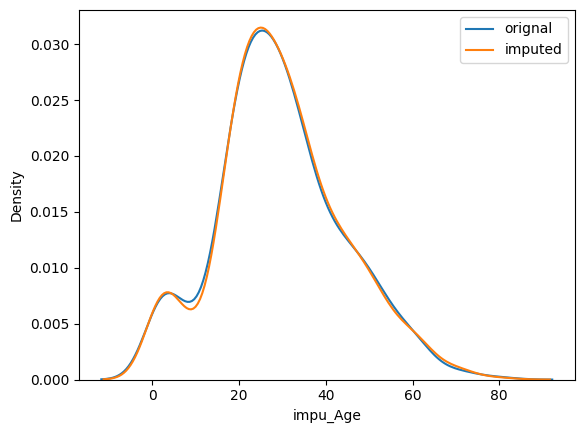

In [38]:
sns.distplot(x_train['Age'],label='orignal',hist=False)
sns.distplot(x_train['impu_Age'],label='imputed',hist=False)
plt.legend()
plt.show()

In [39]:
# see the grapgh all most same the both grapgh

In [40]:
#varience
print("orignal values",x_train['Age'].var())
print("imputed values",x_train['impu_Age'].var())     # see same the varience

orignal values 210.2517072477438
imputed values 210.15768801972214


In [43]:
# covarience
x_train[['Age','Fare','impu_Age']].cov()

,Age,Fare,impu_Age
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,51.153099
impu_Age,210.251707,51.153099,210.157688
